In [1]:
#!/usr/bin/env python3
from pathlib import Path
import shutil

# ----- configure ------------------------------------------------------------
SRC_ROOT   = Path("./../data/datasets/idol/")          # contains building1/, building2/, …
DEST_ROOT  = Path("./../data/datasets/idol_dataset/")  # will hold all renamed files
MOVE_FILES = False                          # True → move, False → copy
# -------------------------------------------------------------------------- #

DEST_ROOT.mkdir(parents=True, exist_ok=True)

known_names, unknown_names = [], []
next_idx = {}                               # keeps per-building counter

# ---------- 1) DATA FILES --------------------------------------------------- #
for bdir in sorted(SRC_ROOT.glob("building[0-9]*")):          # building1, building2 …
    building = bdir.name
    counter  = 0

    for label in ("known", "unknown"):
        sdir = bdir / label
        if not sdir.is_dir():
            continue

        for src in sorted(sdir.iterdir()):                    # file 0.*, 1.*, …
            if src.is_dir():
                continue

            new_name = f"{building}_{counter}{src.suffix}"
            dest     = DEST_ROOT / new_name
            new_img_name = f"{building}_{counter}.png"
            img_dest     = DEST_ROOT / new_img_name
            img_name = f"{building}.png"
            img = SRC_ROOT / img_name
            shutil.move(src, dest) if MOVE_FILES else shutil.copy2(src, dest)
            shutil.move(img, img_dest) if MOVE_FILES else shutil.copy2(img, img_dest)

            (known_names if label == "known" else unknown_names).append(new_name[:-8])
            counter += 1

    next_idx[building] = counter              # remember where we stopped

# ---------- 2) PNG IMAGES --------------------------------------------------- #
# for img in SRC_ROOT.glob("building[0-9]*.png"):               # building1.png …
#     building = img.stem                     # "building1"
#     counter  = next_idx.get(building, 0)    # 0 if building had no data files
#     new_name = f"{building}_{counter}.png"
#     dest     = DEST_ROOT / new_name
#     shutil.move(img, dest) if MOVE_FILES else shutil.copy2(img, dest)

# # ---------- 3) MANIFESTS ---------------------------------------------------- #
(DEST_ROOT / "known.txt"   ).write_text("\n".join(known_names)   + "\n")
(DEST_ROOT / "unknown.txt" ).write_text("\n".join(unknown_names) + "\n")

print(f"Finished.\n  ↳ {len(known_names)} known files\n  ↳ {len(unknown_names)} unknown files\n"
      f"  ↳ {len(list(SRC_ROOT.glob('building[0-9]*.png')))} images processed")

# --------------------------------------------------------------------------- #
#  YAML-generation for each map image
# --------------------------------------------------------------------------- #
#
# Required pip packages:
#   pip install pillow pyyaml
#
from PIL import Image
import yaml

# --------------------------------------------------------------------------- #
#  PARAMETERS you must fill in once
# --------------------------------------------------------------------------- #
FREE_THRESH         = 0.99         # example: probability below this = free
ORIGIN_BY_BUILDING  = {           # metres ↙ bottom-left corner in world coords
    "building1": [14.023, 5.2],
    "building2": [22.5,   22.1],
    "building3": [60.960, 10.973],
}
WORLD_SIZE_BY_BUILDING  = {           # metres ↙ bottom-left corner in world coords
    "building1": [54, 18],
    "building2": [69., 54.],
    "building3": [121,    102.5],
}

#------------------------------------------------------- #

for png_path in DEST_ROOT.glob("building*_*.png"):
    building   = png_path.stem.split("_")[0]          # "building1"
    origin_xy  = ORIGIN_BY_BUILDING.get(building)
    world_size  = WORLD_SIZE_BY_BUILDING.get(building)

    # --- compute world-size from image dimensions -------------------------- #
    # w_px, h_px = Image.open(png_path).size            # (width, height) in px
    # world_size = [w_px * RESOLUTION_M_PER_PX,
    #               h_px * RESOLUTION_M_PER_PX]         # [x, y] in metres

    yaml_data = {
        "image": str(png_path.resolve()),
        "world_size": world_size,                     # [x, y]
        "origin": origin_xy,                          # [x_o, y_o]
        "free_thresh": FREE_THRESH,                # thresh
        "map_name": building
    }

    yaml_path = png_path.with_suffix(".yaml")
    def _represent_list_flow(dumper, data):
        return dumper.represent_sequence("tag:yaml.org,2002:seq", data, flow_style=True)

    yaml.SafeDumper.add_representer(list, _represent_list_flow)

    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(yaml_data, f, sort_keys=False)

    print(f"YAML created → {yaml_path.name}")

Finished.
  ↳ 94 known files
  ↳ 36 unknown files
  ↳ 3 images processed
YAML created → building3_28.yaml
YAML created → building3_26.yaml
YAML created → building1_15.yaml
YAML created → building1_35.yaml
YAML created → building3_21.yaml
YAML created → building1_10.yaml
YAML created → building3_19.yaml
YAML created → building1_30.yaml
YAML created → building3_20.yaml
YAML created → building1_69.yaml
YAML created → building2_16.yaml
YAML created → building1_37.yaml
YAML created → building1_66.yaml
YAML created → building1_52.yaml
YAML created → building1_22.yaml
YAML created → building3_16.yaml
YAML created → building1_8.yaml
YAML created → building1_51.yaml
YAML created → building3_27.yaml
YAML created → building1_64.yaml
YAML created → building1_71.yaml
YAML created → building3_14.yaml
YAML created → building2_9.yaml
YAML created → building1_16.yaml
YAML created → building1_0.yaml
YAML created → building1_26.yaml
YAML created → building1_27.yaml
YAML created → building3_7.yaml
YAML cr

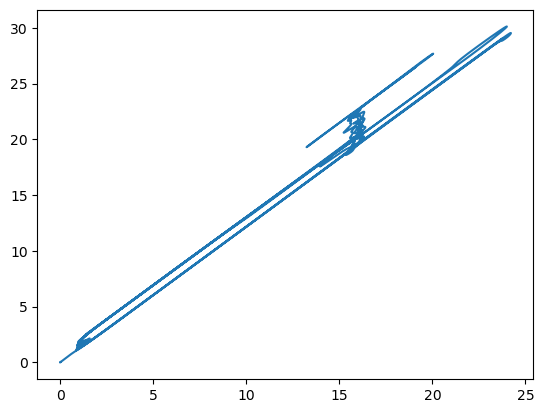

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data_path = './../data/datasets/idol_dataset/building2_0'
df = pd.read_feather(data_path + '.feather')
# theta = 0.2822
theta = 1.8510
# positions[:, 0] = positions[:, 0]*np.cos(theta) - positions[:, 1]*np.sin(theta)
df['processedPosX'] = df['processedPosX']*np.cos(theta) - df['processedPosY']*np.sin(theta)
# positions[:, 1] = positions[:, 0]*np.sin(theta) + positions[:, 1]*np.cos(theta)
df['processedPosY'] = df['processedPosX']*np.sin(theta) + df['processedPosY']*np.cos(theta)

# positions = np.stack([x, y], axis=1)
positions = df[['processedPosX', 'processedPosY']].values
plt.plot(positions[:, 0], positions[:, 1])
plt.show()